In [1]:
# Celda con Imports y configuración básica
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

# Integrador Symplectico mediante Extensión Hamiltoniana + Splitting + Método de Strang

Este cuaderno implementa el método geométrico clásico para integrar sistemas Hamiltonianos
**no autónomos** mediante:

1. **Extensión a un sistema autónomo symplectico**,  
2. **Splitting del Hamiltoniano extendido**,  
3. **Composición simétrica (Strang) de los flujos integrables**.

Trabajamos con una partícula cargada en dimensión $d = 2$ o $d = 3$,
sujeta a un campo eléctrico dependiente del tiempo $E(t) \in \mathbb{R}^d$.


---

## 1. Hamiltoniano original (no autónomo)

Sea $q, p \in \mathbb{R}^d$ la posición y el momento de la partícula.
El campo eléctrico espacialmente homogéneo es $E(t)$.

El Hamiltoniano físico es:

$$
H(q,p,t) = \frac{ \|p\|^2 }{2m} - e\, q \cdot E(t).
$$

Ecuaciones de Hamilton:

$$
\dot q = \frac{p}{m},
\qquad
\dot p = e\,E(t),
\qquad
\dot t = 1.
$$

Como depende explícitamente de $t$, este sistema **no es autónomo**.


---

## 2. Extensión a un sistema autónomo symplectico

Introducimos una nueva variable $E$ (energía extendida), conjugada a $t$.
Las coordenadas extendidas son:

$$
(q,p,t,E) \in \mathbb{R}^{2d+2}.
$$

El Hamiltoniano extendido es:

$$
\widehat H(q,p,t,E) 
= H(q,p,t) + E
= \frac{\|p\|^2}{2m} - e\, q\cdot E(t) + E.
$$

La forma symplectica extendida es:

$$
\Omega = \sum_{i=1}^d dq_i \wedge dp_i + dE \wedge dt.
$$

Las ecuaciones de Hamilton en el espacio extendido:

$$
\dot q = \frac{p}{m},
\qquad
\dot p = e\, E(t),
$$

$$
\dot t = 1,
\qquad
\dot E = e\, q\cdot \dot E(t).
$$

Ahora el sistema **es autónomo y symplectico**.


---

## 3. Splitting del Hamiltoniano extendido

Escribimos:

$$
\widehat H = A + B,
$$

con:

$$
A(q,p,t,E) = \frac{\|p\|^2}{2m} + \frac12 E,
$$

$$
B(q,p,t,E) = -e\, q\cdot E(t) + \frac12 E.
$$

Ambos poseen flujos integrables analíticamente.


---

## 4. Flujos de $A$ y $B$

### 4.1 Flujo de $A$

$$
A = \frac{\|p\|^2}{2m} + \frac12 E.
$$

Ecuaciones:

$$
\dot q = \frac{p}{m},\quad
\dot p = 0,\quad
\dot t = \frac12,\quad
\dot E = 0.
$$

Solución exacta (paso $\tau$):

$$
q \gets q + \frac{\tau}{m} p,
\qquad
p \gets p,
$$

$$
t \gets t + \frac{\tau}{2},
\qquad
E \gets E.
$$


---

### 4.2 Flujo de $B$

$$
B = -e\, q\cdot E(t) + \frac12 E.
$$

Ecuaciones:

$$
\dot q = 0,
\qquad
\dot p = e\, E(t),
$$

$$
\dot t = \frac12,
\qquad
\dot E = e\, q \cdot \dot E(t).
$$

Como $q$ no cambia, usamos un esquema de orden 2 basado en el punto medio:

$$
p \gets p + \tau\, e\, E(t + \tfrac{\tau}{2}),
$$

$$
E \gets E + \tau\, e\, q\cdot \dot E(t + \tfrac{\tau}{2}),
$$

$$
t \gets t + \frac{\tau}{2}.
$$


---

## 5. Integrador de Strang (orden 2)

La composición simétrica:

$$
\Phi_{\Delta t}
=
\varphi_A^{\Delta t/2}
\circ
\varphi_B^{\Delta t}
\circ
\varphi_A^{\Delta t/2}
$$

es:

- **symplectica** en el espacio extendido,
- **de orden 2**,
- **estable a largo plazo**.


---

## 6. Pseudocódigo del integrador Strang

```python
def strang_step(q, p, t, E, dt, e, m, E_func, E_dot_func):

    # ---- A-step (half) ----
    q = q + 0.5 * dt * (p / m)
    t = t + 0.5 * dt * 0.5
    # p, E unchanged

    # ---- B-step (full) ----
    t_mid = t + 0.5 * dt * 0.5     # punto medio

    p = p + dt * e * E_func(t_mid)
    E = E + dt * e * q.dot(E_dot_func(t_mid))
    t = t + dt * 0.5

    # ---- A-step (half) ----
    q = q + 0.5 * dt * (p / m)
    t = t + 0.5 * dt * 0.5

    return q, p, t, E


In [2]:
#####################################
# Physical and numerical parameters #
#####################################
m: float = 1.0
e: float = 1.0
dt: float = 0.01
steps: int = 2000

In [3]:
###############################
# Electrical field E(t) in 2d #
###############################
def E_func(t: float) -> np.ndarray:
    """
    E.g: sin/cos combination
    """
    return np.array([
        np.sin(0.5*t), 
        np.cos(0.5*t),
    ])

In [4]:
#############################
# Temporal derivate of E(t) #
#############################
def E_dot_func(t: float) -> np.ndarray:
    return np.array([
        0.5*np.cos(0.5*t),
        -0.5*np.sin(0.5*t),
    ])

In [5]:
# ============================
# Hamiltoniano físico H(q,p,t)
# ============================

def H_physical(q: np.ndarray, p: np.ndarray, t: float) -> float:
    """
    H(q,p,t) = |p|^2/(2m) - e q·E(t)
    """
    kinetic = 0.5 * np.dot(p, p) / m
    potential = -e * np.dot(q, E_func(t))
    return kinetic + potential

In [6]:
def strang_step(q, p, t, Eext, dt):
    """
    Un paso de integrador de Strang para el Hamiltoniano extendido:
        H_hat = |p|^2/(2m) - e q·E(t) + Eext
    con splitting H_hat = A + B.

    A: cinético + 1/2 Eext
    B: potencial -e q·E(t) + 1/2 Eext
    """

    # ---- A-step (half) ----
    # Flujo de A durante dt/2:
    #   q'    = q + (dt/2) * p/m
    #   p'    = p
    #   t'    = t + (dt/2) * (1/2)
    #   Eext' = Eext
    q = q + 0.5 * dt * (p / m)
    t = t + 0.5 * dt * 0.5

    # ---- B-step (full) ----
    # Flujo de B durante dt:
    #   q fijo
    #   p'    = p + dt * e E(t_mid)
    #   t'    = t + dt * (1/2)
    #   Eext' = Eext + dt * e q · E_dot(t_mid)
    # Usamos punto medio t_mid para orden 2.
    t_mid = t + 0.5 * dt * 0.5  # tiempo medio interno

    p = p + dt * e * E_func(t_mid)
    Eext = Eext + dt * e * np.dot(q, E_dot_func(t_mid))
    t = t + dt * 0.5

    # ---- A-step (half) otra vez ----
    q = q + 0.5 * dt * (p / m)
    t = t + 0.5 * dt * 0.5

    return q, p, t, Eext


In [7]:
# ============================
# Condiciones iniciales
# ============================

q = np.array([0.0, 0.0])  # posición inicial (2D)
p = np.array([1.0, 0.0])  # momento inicial (2D)
t = 0.0                   # tiempo inicial
Eext = 0.0                # energía extendida inicial

In [8]:
# ============================
# Integración temporal
# ============================

trajectory = []
momenta = []
times = []
H_vals = []
Hext_vals = []

for _ in range(steps):
    # Guardamos estado ANTES del paso
    trajectory.append(q.copy())
    momenta.append(p.copy())
    times.append(t)
    H = H_physical(q, p, t)
    H_vals.append(H)
    Hext_vals.append(H + Eext)

    # Un paso de Strang
    q, p, t, Eext = strang_step(q, p, t, Eext, dt)

trajectory = np.array(trajectory)
momenta = np.array(momenta)
times = np.array(times)
H_vals = np.array(H_vals)
Hext_vals = np.array(Hext_vals)

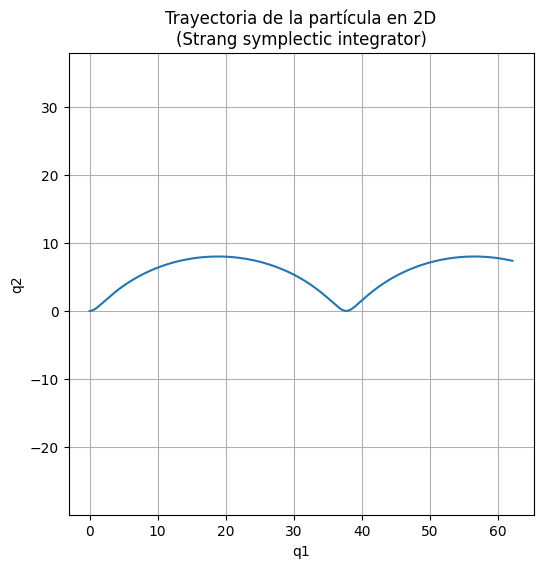

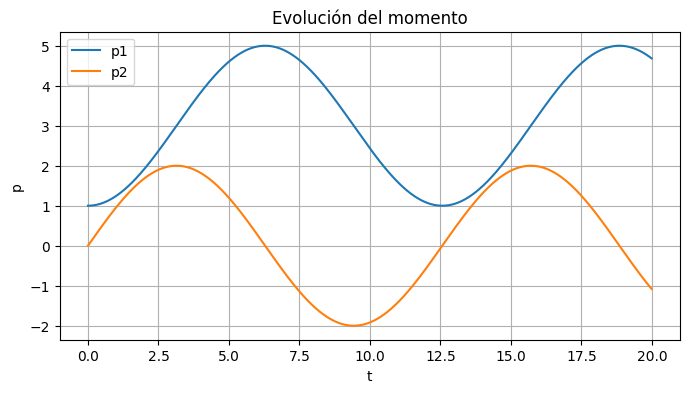

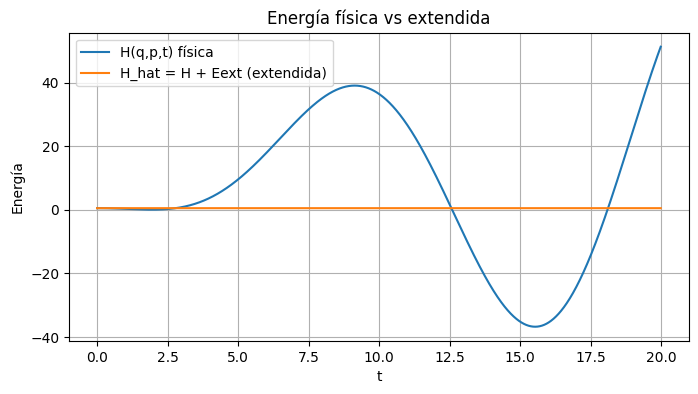

In [9]:
# ============================
# Gráficas
# ============================

# Trayectoria en el plano (q1, q2)
plt.figure(figsize=(6, 6))
plt.plot(trajectory[:, 0], trajectory[:, 1])
plt.title("Trayectoria de la partícula en 2D\n(Strang symplectic integrator)")
plt.xlabel("q1")
plt.ylabel("q2")
plt.grid(True)
plt.axis("equal")
plt.show()

# Componentes del momento en función del tiempo
plt.figure(figsize=(8, 4))
plt.plot(times, momenta[:, 0], label="p1")
plt.plot(times, momenta[:, 1], label="p2")
plt.title("Evolución del momento")
plt.xlabel("t")
plt.ylabel("p")
plt.legend()
plt.grid(True)
plt.show()

# Energía física y energía extendida
plt.figure(figsize=(8, 4))
plt.plot(times, H_vals, label="H(q,p,t) física")
plt.plot(times, Hext_vals, label="H_hat = H + Eext (extendida)")
plt.title("Energía física vs extendida")
plt.xlabel("t")
plt.ylabel("Energía")
plt.legend()
plt.grid(True)
plt.show()

## 7. Backward error analysis (BEA) para el integrador symplectico extendido

Una de las ideas clave para entender por qué los integradores symplecticos se comportan tan bien a largo plazo es el **backward error analysis** (BEA).

La idea, de forma informal, es la siguiente:

- El integrador numérico symplectico no sigue exactamente el flujo del Hamiltoniano original $\widehat H$,  
- pero **sí es exactamente el flujo de un Hamiltoniano "modificado"** $\widehat H_{\text{mod}}$ muy cercano a $\widehat H$.

Más precisamente, para un integrador symplectico de orden 2 aplicado al sistema extendido,

$$
\widehat H_{\text{mod}}
= \widehat H 
  + \Delta t^2 H_2 
  + \Delta t^4 H_4 
  + \cdots,
$$

donde:

- $\Delta t$ es el tamaño de paso,
- $H_2, H_4, \dots$ son correcciones "pequeñas" (en sentido asintótico),
- y existe un cambio de variables casi identidad tal que el mapa numérico en tiempo $n \Delta t$ coincide con el flujo exacto de $\widehat H_{\text{mod}}$ (hasta errores muy pequeños).

Consecuencias importantes:

1. **Casi-conservación de la energía extendida.**  
   Como $\widehat H_{\text{mod}}$ es un Hamiltoniano autónomo, su energía se conserva exactamente a lo largo del flujo modificado. Por eso, en la práctica, el integrador muestra una energía extendida $H(q,p,t) + E$ que:
   - oscila alrededor de un valor casi constante,
   - pero **no deriva secularmente** como en métodos no symplecticos (por ejemplo, RK4).

2. **Buen comportamiento cualitativo a largo plazo.**  
   El hecho de que el método siga el flujo de un Hamiltoniano cercano a $\widehat H$ implica que preserva bien:
   - estructuras invariantes (toros, separatrices, etc.),
   - fenómenos de difusión lenta,
   - y, en general, la **geometría global de la dinámica**.

3. **En el contexto co-symplectico.**  
   Nuestro sistema no autónomo original $(q,p,t)$ se ve como la proyección del sistema extendido symplectico $(q,p,t,E)$.  
   El BEA en el espacio extendido equivale a decir que:
   - las trayectorias numéricas proyectadas en $(q,p,t)$ siguen el flujo de un sistema co-simplectico modificado,
   - lo que explica por qué reproducen correctamente fenómenos cualitativos (por ejemplo, energía que intercambia de forma coherente con el campo, difusión lenta, invariantes aproximados, etc.).

En resumen:

> El integrador por extensión + Strang **no está resolviendo exactamente** el sistema original, pero **sí está resolviendo exactamente** un sistema Hamiltoniano muy cercano.  
> Esa es la razón profunda detrás de la buena conservación a largo plazo de cantidades geométricas y del comportamiento estable del método.
